In [1]:
import numpy as np
import torch
import json
import boto3
import pandas as pd


s3 = boto3.client('s3')
bucket_name = "s3://rl6-reinforcement-learning-01"
output_dir = "behavioral-cloning"

exp_path = {
    # "20_old": "exp_20/20260116_171518_ba080b55",
    # "21_old": "exp_21/20260116_171518_62e0ee07",
    # "22_old": "exp_22/20260116_171518_23e169c1",
    "20": "exp_20/20260116_181413_ea49c22d",
    "21": "exp_21/20260116_181413_656b8c11",
    "22": "exp_22/20260116_181413_3f6c489f",
}

metrics_name = "metrics.json"

def load_metrics_from_s3(exp_id):
    exp_folder = exp_path[exp_id]
    s3_key = f"{output_dir}/{exp_folder}/{metrics_name}"
    response = s3.get_object(Bucket=bucket_name.replace("s3://", ""), Key=s3_key)
    metrics_data = response['Body'].read().decode('utf-8')
    metrics = json.loads(metrics_data)
    return metrics

metrics_per_exp = {}
for exp_id in exp_path.keys():
    try:
        metrics_raw = load_metrics_from_s3(exp_id)
        metrics_per_exp[exp_id] = pd.DataFrame(metrics_raw).T
        metrics_per_exp[exp_id].index = metrics_per_exp[exp_id].index.map(int)

    except Exception as e:
        print(f"Failed to load metrics for experiment {exp_id}: {e}")

len(metrics_per_exp)

3

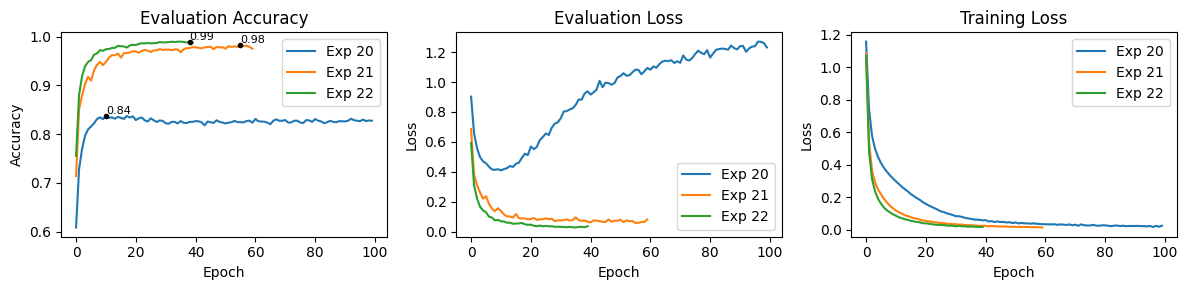

In [2]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(3*4, 3))
for exp_id, df in metrics_per_exp.items():
    axs[0].plot(df['eval_acc'], label=f'Exp {exp_id}')
    axs[1].plot(df['eval_loss'], label=f'Exp {exp_id}')
    axs[2].plot(df['train_loss'], label=f'Exp {exp_id}')

# Plot best accuracy points and text
for exp_id, df in metrics_per_exp.items():
    best_epoch = df['eval_acc'].idxmax()
    best_acc = df['eval_acc'].max()
    axs[0].plot(best_epoch, best_acc, '.', color="black")  # Mark the best point
    axs[0].text(best_epoch, best_acc, f'{best_acc:.2f}', fontsize=8, verticalalignment='bottom')

axs[0].set_title('Evaluation Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

axs[1].set_title('Evaluation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()

axs[2].set_title('Training Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()

plt.tight_layout()
plt.show()